In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

In [2]:
df = pd.read_csv('/content/train.csv')

In [ ]:
print(f"Dataset Shape: {df.shape}")
print(f"Total Rows: {df.shape[0]}, Total Columns: {df.shape[1]}")
df.head()

In [ ]:
features = ['GrLivArea', 'BedroomAbvGr', 'FullBath', 'SalePrice']
data = df[features].copy()

print("=== Dataset Info ===")
print(data.info())
print()
print("=== Statistical Summary ===")
data.describe().round(2)

In [ ]:
print("=== Missing Values ===")
missing = data.isnull().sum()
print(missing)
print()
if missing.sum() == 0:
    print("✅ No missing values found!")
else:
    print("⚠️ Missing values detected — will handle below.")


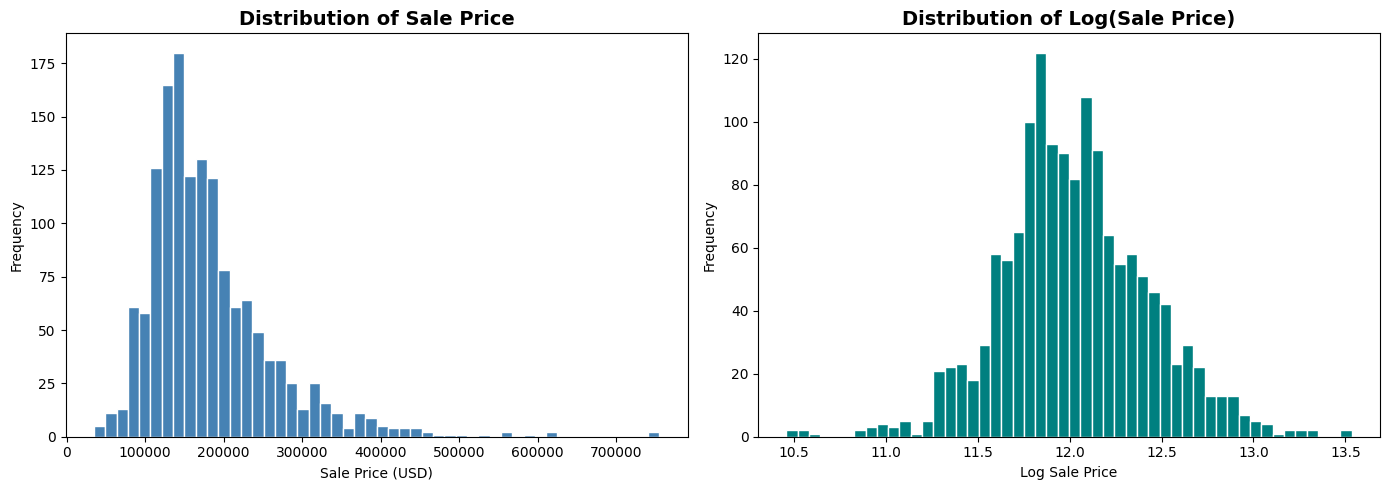

In [10]:
# Distribution of SalePrice (target variable)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(data['SalePrice'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Distribution of Sale Price', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Sale Price (USD)')
axes[0].set_ylabel('Frequency')

axes[1].hist(np.log1p(data['SalePrice']), bins=50, color='teal', edgecolor='white')
axes[1].set_title('Distribution of Log(Sale Price)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Log Sale Price')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.savefig('price_distribution.png', dpi=150, bbox_inches='tight')
plt.show()


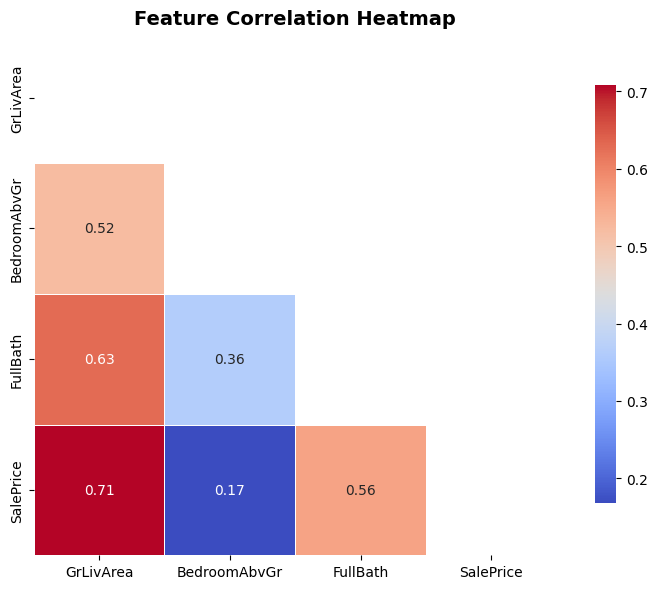

In [11]:
# Correlation heatmap
plt.figure(figsize=(8, 6))
corr = data.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            mask=mask, linewidths=0.5, square=True,
            cbar_kws={'shrink': 0.8})
plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()


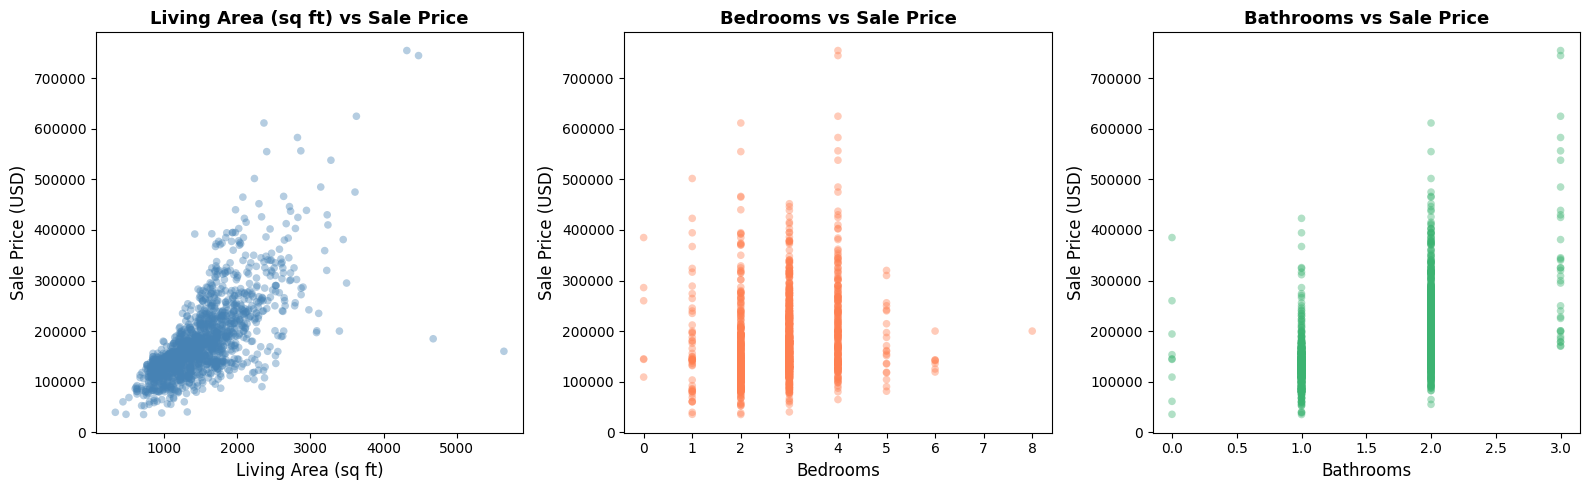

In [12]:
# Scatter plots: each feature vs SalePrice
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
feature_cols = ['GrLivArea', 'BedroomAbvGr', 'FullBath']
colors = ['steelblue', 'coral', 'mediumseagreen']
labels = ['Living Area (sq ft)', 'Bedrooms', 'Bathrooms']

for ax, feat, color, label in zip(axes, feature_cols, colors, labels):
    ax.scatter(data[feat], data['SalePrice'], alpha=0.4, color=color, edgecolors='none', s=30)
    ax.set_xlabel(label, fontsize=12)
    ax.set_ylabel('Sale Price (USD)', fontsize=12)
    ax.set_title(f'{label} vs Sale Price', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('feature_scatter_plots.png', dpi=150, bbox_inches='tight')
plt.show()

In [13]:
# Drop rows with any missing values (if any)
data = data.dropna()
print(f"Shape after dropping nulls: {data.shape}")

# Define features (X) and target (y)
X = data[['GrLivArea', 'BedroomAbvGr', 'FullBath']]
y = data['SalePrice']

print(f"\nFeatures shape: {X.shape}")
print(f"Target shape:   {y.shape}")
print("\n✅ Features and target defined successfully!")


Shape after dropping nulls: (1460, 4)

Features shape: (1460, 3)
Target shape:   (1460,)

✅ Features and target defined successfully!


In [14]:
# Split into training and testing sets (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training set size:  {X_train.shape[0]} samples")
print(f"Testing set size:   {X_test.shape[0]} samples")

# Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("\n✅ Data split and scaled successfully!")


Training set size:  1168 samples
Testing set size:   292 samples

✅ Data split and scaled successfully!


In [15]:
# Initialize and train the model
model = LinearRegression()
model.fit(X_train_scaled, y_train)

print("✅ Model trained successfully!")
print()
print("=== Model Coefficients ===")
coef_df = pd.DataFrame({
    'Feature': ['GrLivArea', 'BedroomAbvGr', 'FullBath'],
    'Coefficient': model.coef_.round(2)
})
print(coef_df.to_string(index=False))
print(f"\nIntercept: ${model.intercept_:,.2f}")
print()
print("💡 A positive coefficient means the feature increases the house price.")
print("💡 A negative coefficient means the feature decreases the house price.")


✅ Model trained successfully!

=== Model Coefficients ===
     Feature  Coefficient
   GrLivArea     54531.44
BedroomAbvGr    -21444.35
    FullBath     16408.18

Intercept: $181,441.54

💡 A positive coefficient means the feature increases the house price.
💡 A negative coefficient means the feature decreases the house price.


In [19]:
# Make predictions
y_pred = model.predict(X_test_scaled)

# Calculate metrics
mae  = mean_absolute_error(y_test, y_pred)
mse  = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2   = r2_score(y_test, y_pred)

print("MODEL EVALUATION RESULTS")
print(f"  R² Score                : {r2:.4f}")
print(f"  Mean Absolute Error     : ${mae:,.2f}")
print(f"  Mean Squared Error      : ${mse:,.2f}")
print(f"  Root Mean Squared Error : ${rmse:,.2f}")
print()
print(f"💡 R² = {r2:.2f} means the model explains {r2*100:.1f}% of the variance in house prices.")


MODEL EVALUATION RESULTS
  R² Score                : 0.6341
  Mean Absolute Error     : $35,788.06
  Mean Squared Error      : $2,806,426,667.25
  Root Mean Squared Error : $52,975.72

💡 R² = 0.63 means the model explains 63.4% of the variance in house prices.


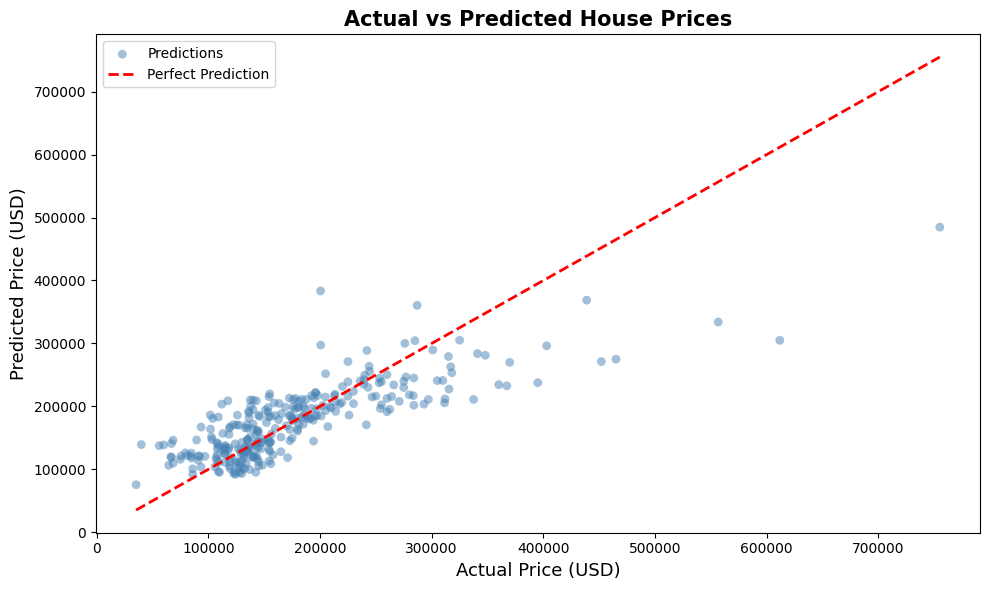

💡 Points closer to the red dashed line = more accurate predictions.


In [20]:
# Actual vs Predicted scatter plot
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.5, color='steelblue', edgecolors='none', s=40, label='Predictions')
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--', linewidth=2, label='Perfect Prediction')

plt.xlabel('Actual Price (USD)', fontsize=13)
plt.ylabel('Predicted Price (USD)', fontsize=13)
plt.title('Actual vs Predicted House Prices', fontsize=15, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.savefig('actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()
print("💡 Points closer to the red dashed line = more accurate predictions.")


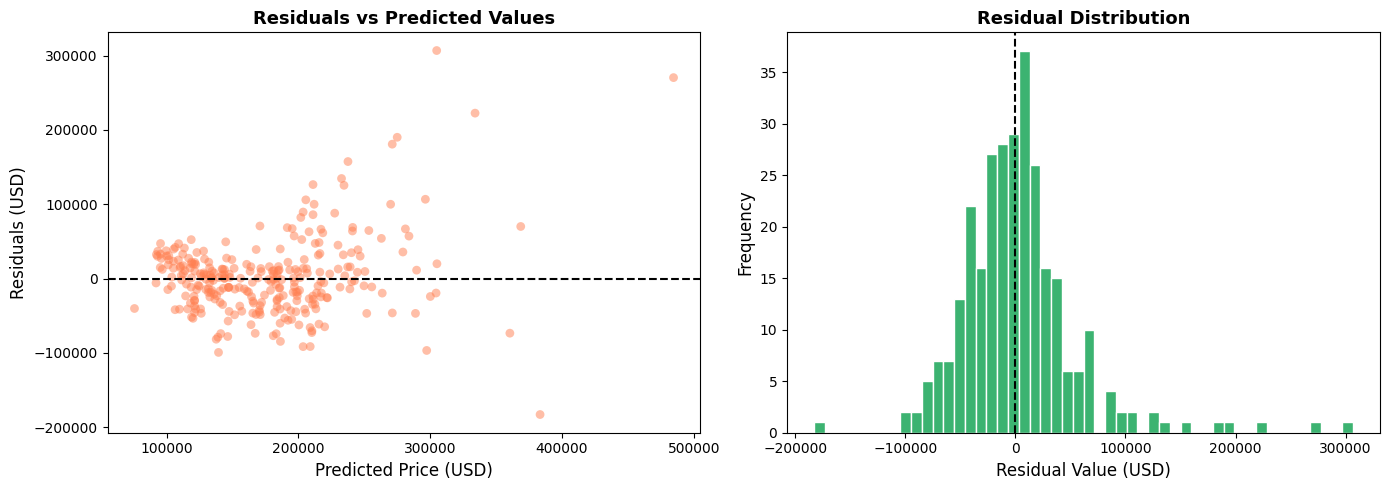

In [21]:
# Residuals plot
residuals = y_test - y_pred

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Residuals vs Predicted
axes[0].scatter(y_pred, residuals, alpha=0.5, color='coral', edgecolors='none', s=40)
axes[0].axhline(y=0, color='black', linestyle='--', linewidth=1.5)
axes[0].set_xlabel('Predicted Price (USD)', fontsize=12)
axes[0].set_ylabel('Residuals (USD)', fontsize=12)
axes[0].set_title('Residuals vs Predicted Values', fontsize=13, fontweight='bold')

# Residual distribution
axes[1].hist(residuals, bins=50, color='mediumseagreen', edgecolor='white')
axes[1].axvline(x=0, color='black', linestyle='--', linewidth=1.5)
axes[1].set_xlabel('Residual Value (USD)', fontsize=12)
axes[1].set_ylabel('Frequency', fontsize=12)
axes[1].set_title('Residual Distribution', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('residual_plots.png', dpi=150, bbox_inches='tight')
plt.show()


In [24]:
def predict_house_price(sqft, bedrooms, bathrooms):

    input_data = pd.DataFrame([[sqft, bedrooms, bathrooms]],
    columns=['GrLivArea', 'BedroomAbvGr', 'FullBath'])

    input_scaled = scaler.transform(input_data)
    predicted_price = model.predict(input_scaled)[0]
    return predicted_price

# ── Test examples
examples = [
    (1500, 3, 2),
    (2500, 4, 3),
    (800,  2, 1),
    (3500, 5, 4),
]
print("     🏠 CUSTOM HOUSE PRICE PREDICTIONS")
print(f"  {'Sq Ft':>6}  {'Beds':>5}  {'Baths':>6}  {'Predicted Price':>16}")
for sqft, beds, baths in examples:
    price = predict_house_price(sqft, beds, baths)
    print(f"  {sqft:>6}  {beds:>5}  {baths:>6}  ${price:>15,.2f}")



     🏠 CUSTOM HOUSE PRICE PREDICTIONS
   Sq Ft   Beds   Baths   Predicted Price
    1500      3       2  $     188,364.36
    2500      4       3  $     295,749.83
     800      2       1  $     112,186.79
    3500      5       4  $     403,135.29
